# VM Behavioural Clustering

Load and preserve the source data before feature engineering or cleaning.

In [7]:
%pip install matplotlib seaborn scikit-learn

  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------  9.2/9.3 MB 48.3 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 18.8 MB/s  0:00:00
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 8.2/8.2 MB 36.5 MB/s  0:00:00
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 37.3 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------  7.1/7.2 MB 82.9 MB/s eta 0:00:01
   ---------------------------------------  7.1/7.2 MB 82.9 MB/s eta 0:00:01
   ------------

In [8]:
# Reproducible notebook setup
from pathlib import Path
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 100)

Matplotlib is building the font cache; this may take a moment.


In [9]:
# Load source tables
DATA_DIR = Path.cwd()

vm_info = pd.read_csv(DATA_DIR / 'vm_info.csv')
vm_utilization = pd.read_csv(DATA_DIR / 'vm_utilization_timeseries.csv')
cpu_type_definitions = pd.read_csv(DATA_DIR / 'cpu_type_definitions.csv')
memory_type_definitions = pd.read_csv(DATA_DIR / 'memory_type_definitions.csv')

# Immutable-in-practice backups: retain these unchanged throughout cleaning and analysis.
vm_info_raw = vm_info.copy(deep=True)
vm_utilization_raw = vm_utilization.copy(deep=True)

print(f'VM metadata: {vm_info.shape[0]:,} rows × {vm_info.shape[1]} columns')
print(f'Utilization readings: {vm_utilization.shape[0]:,} rows × {vm_utilization.shape[1]} columns')

VM metadata: 1,500 rows × 8 columns
Utilization readings: 765,189 rows × 8 columns


In [10]:
# Standardize the two same-structured size lookup tables and stack them into one reference table.
cpu_reference = (
    cpu_type_definitions
    .rename(columns={'core_count_bucket': 'size_bucket'})
    .assign(resource_type='cpu')
)
memory_reference = (
    memory_type_definitions
    .rename(columns={'memory_bucket': 'size_bucket'})
    .assign(resource_type='memory')
)

size_bucket_reference = pd.concat(
    [cpu_reference, memory_reference],
    ignore_index=True,
)

size_bucket_reference

,size_bucket,bucket_category,min_value,max_value,representative_value,resource_type
0,small_2_4,cores,2,4,2,cpu
1,medium_4_8,cores,4,8,4,cpu
2,large_8_16,cores,8,16,8,cpu
3,xlarge_16_32,cores,16,32,16,cpu
4,xxlarge_32_64,cores,32,64,32,cpu
5,small_4_8,memory_gb,4,8,4,memory
6,medium_8_16,memory_gb,8,16,8,memory
7,large_16_32,memory_gb,16,32,16,memory
8,xlarge_32_64,memory_gb,32,64,32,memory
9,xxlarge_64_128,memory_gb,64,128,64,memory


## Raw data quality audit

This audit uses the loaded source tables before any cleaning or feature engineering.

In [11]:
from contextlib import redirect_stdout
from io import StringIO

OUTPUT_DIR = DATA_DIR / 'outputs'
REPORT_PATH = OUTPUT_DIR / 'raw_data_quality_report.txt'

def audit_table(name, table):
    print(f'\n{"=" * 80}\n{name}\n{"=" * 80}')
    print(f'Rows: {len(table):,} | Columns: {table.shape[1]:,}')
    print('\nData types:')
    print(table.dtypes.to_string())
    print('\nMissing values:')
    print(table.isna().sum().to_string())

def run_raw_data_quality_audit():
    audit_table('VM metadata (vm_info)', vm_info)
    audit_table('Utilization readings (vm_utilization)', vm_utilization)
    audit_table('Combined size-bucket lookup (size_bucket_reference)', size_bucket_reference)

    print(f'\n{"=" * 80}\nVM lifecycle timestamp review\n{"=" * 80}')
    creation_missing = vm_info['vm_created_ts'].isna().sum()
    deletion_missing = vm_info['vm_deleted_ts'].isna().sum()
    print(f'Missing vm_created_ts: {creation_missing:,}')
    print('Meaning: a missing creation timestamp has no lifecycle-state meaning in the data dictionary; it is a data-quality gap to investigate.')
    print(f'\nMissing vm_deleted_ts: {deletion_missing:,}')
    print('Meaning: a missing deletion timestamp means the VM is still active.')

    readings_per_vm = vm_utilization.groupby('vm_id').size().rename('telemetry_readings')
    print(f'\n{"=" * 80}\nTelemetry coverage per VM\n{"=" * 80}')
    print(f'VMs with at least one utilization reading: {readings_per_vm.size:,}')
    print('\nUtilization-reading count distribution:')
    print(readings_per_vm.describe().to_string())
    print(f'\nVMs with fewer than the maximum ({readings_per_vm.max():,}) readings: {(readings_per_vm < readings_per_vm.max()).sum():,}')

    metadata_vm_ids = set(vm_info['vm_id'].dropna())
    utilization_vm_ids = set(readings_per_vm.index.dropna())
    metadata_without_telemetry = metadata_vm_ids - utilization_vm_ids
    telemetry_without_metadata = utilization_vm_ids - metadata_vm_ids

    print(f'\n{"=" * 80}\nVM ID reconciliation\n{"=" * 80}')
    print(f'Unique VMs in metadata: {len(metadata_vm_ids):,}')
    print(f'Unique VMs in utilization: {len(utilization_vm_ids):,}')
    print(f'Metadata VMs without telemetry: {len(metadata_without_telemetry):,}')
    print(f'Utilization VMs without metadata: {len(telemetry_without_metadata):,}')
    print(f'VM populations line up exactly: {metadata_vm_ids == utilization_vm_ids}')

    if metadata_without_telemetry:
        print(f'Example metadata-only VM IDs: {sorted(metadata_without_telemetry)[:10]}')
    if telemetry_without_metadata:
        print(f'Example utilization-only VM IDs: {sorted(telemetry_without_metadata)[:10]}')

    return readings_per_vm

audit_buffer = StringIO()
with redirect_stdout(audit_buffer):
    telemetry_readings_per_vm = run_raw_data_quality_audit()

raw_data_quality_report = audit_buffer.getvalue()
print(raw_data_quality_report)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_PATH.write_text(raw_data_quality_report, encoding='utf-8')
print(f'Raw data quality report saved to: {REPORT_PATH}')


VM metadata (vm_info)
Rows: 1,500 | Columns: 8

Data types:
vm_id                 object
subscription_id       object
deployment_id         object
vm_created_ts          int64
vm_deleted_ts        float64
vm_category           object
core_count_bucket     object
memory_bucket         object

Missing values:
vm_id                   0
subscription_id         0
deployment_id           0
vm_created_ts           0
vm_deleted_ts        1338
vm_category             0
core_count_bucket       0
memory_bucket           0

Utilization readings (vm_utilization)
Rows: 765,189 | Columns: 8

Data types:
vm_id               object
timestamp            int64
min_cpu_5min       float64
max_cpu_5min       float64
avg_cpu_5min       float64
min_memory_5min    float64
max_memory_5min    float64
avg_memory_5min    float64

Missing values:
vm_id              0
timestamp          0
min_cpu_5min       0
max_cpu_5min       0
avg_cpu_5min       0
min_memory_5min    0
max_memory_5min    0
avg_memory_5min    0

C

# Exploratory Data Analysis

## Per-VM utilization summary and fleet distributions

Per-VM utilization summary: 1,499 VMs


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
telemetry_readings,1499.0,510.466311,126.476495,2.000000,27.980000,159.800000,553.000000,558.000000,561.000000,565.000000,567.020000,571.000000
average_cpu_utilization_pct,1499.0,26.156459,14.382887,3.472143,3.930115,4.127607,13.917504,27.467115,35.579963,54.888544,55.527277,56.053566
peak_cpu_utilization_pct,1499.0,63.104396,32.300474,8.750000,10.240000,11.570000,30.855000,65.920000,91.105000,100.000000,100.000000,100.000000
average_memory_utilization_pct,1499.0,42.624623,21.856221,8.024946,9.821104,13.485047,24.934608,36.757839,62.652354,79.531747,86.681217,91.412678
peak_memory_utilization_pct,1499.0,53.074937,25.120794,10.760000,12.948800,17.586000,34.425000,46.560000,78.390000,90.957000,97.320600,100.000000


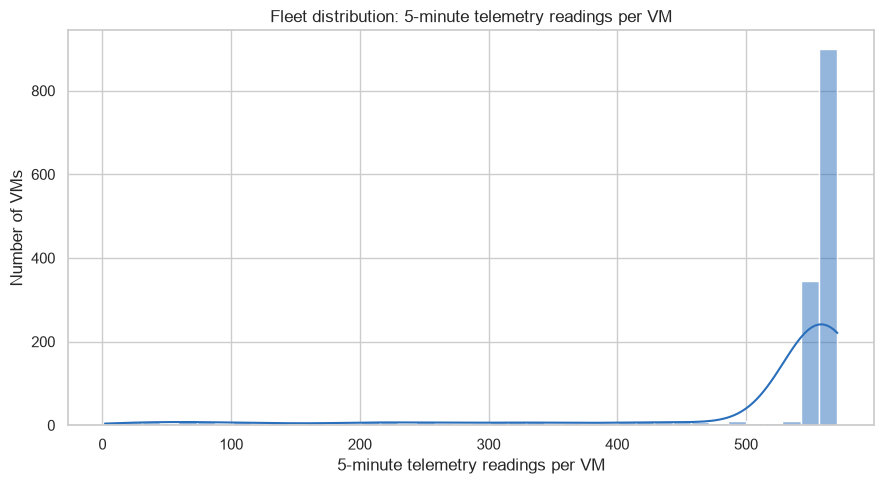

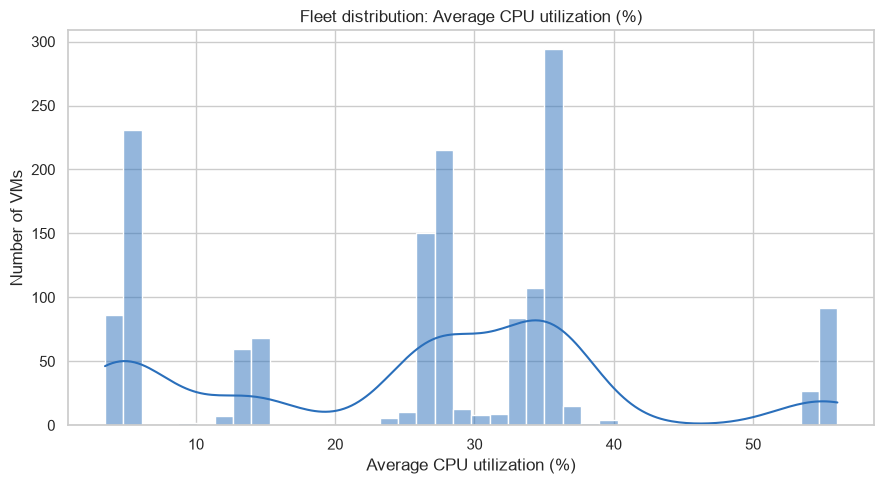

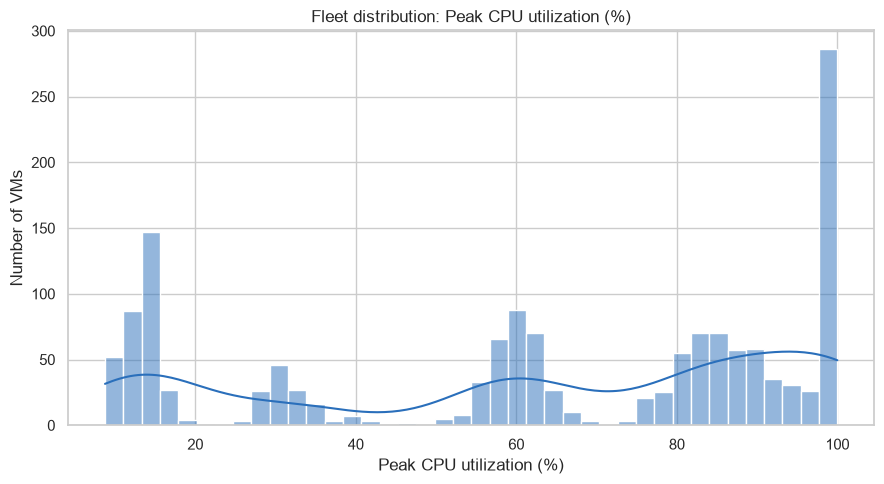

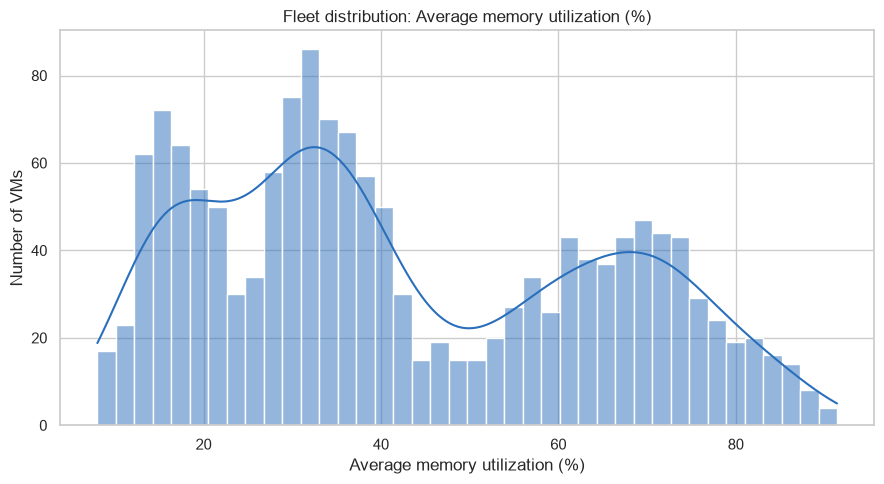

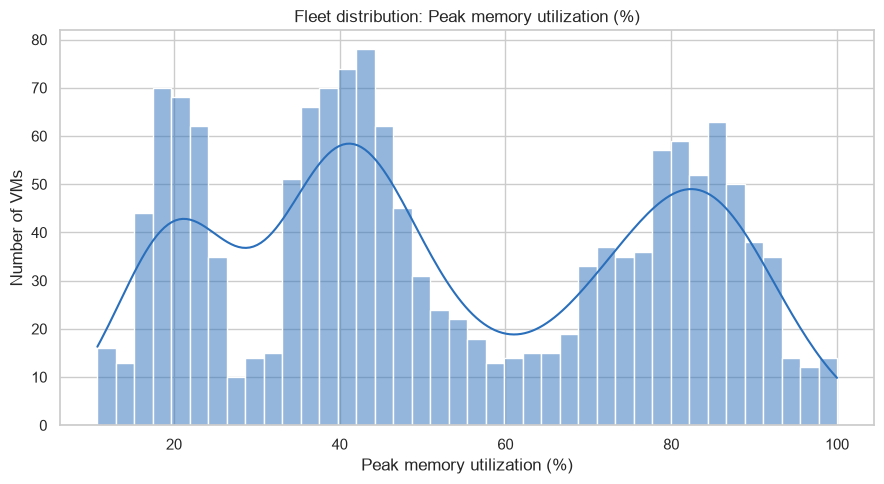

Saved 5 histogram figures to: c:\Users\kdank\OneDrive\Desktop\VM_Segmentation_Project\outputs\figures


,vm_id,telemetry_readings,average_cpu_utilization_pct,peak_cpu_utilization_pct,average_memory_utilization_pct,peak_memory_utilization_pct
0,vm_00000,555,36.713441,64.77,37.984649,47.27
1,vm_00001,557,56.013196,100.00,47.486643,61.47
2,vm_00002,557,14.043124,31.77,75.836643,82.02
3,vm_00003,15,33.130000,52.84,35.998000,42.98
4,vm_00004,555,27.124486,88.32,60.805441,78.39


In [12]:
FIGURES_DIR = OUTPUT_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Aggregate 5-minute readings to one behavioural summary for each VM.
per_vm_utilization_summary = (
    vm_utilization
    .groupby('vm_id', as_index=False)
    .agg(
        telemetry_readings=('timestamp', 'size'),
        average_cpu_utilization_pct=('avg_cpu_5min', 'mean'),
        peak_cpu_utilization_pct=('max_cpu_5min', 'max'),
        average_memory_utilization_pct=('avg_memory_5min', 'mean'),
        peak_memory_utilization_pct=('max_memory_5min', 'max'),
    )
)

usage_metrics = [
    'average_cpu_utilization_pct',
    'peak_cpu_utilization_pct',
    'average_memory_utilization_pct',
    'peak_memory_utilization_pct',
]
summary_metrics = ['telemetry_readings', *usage_metrics]

# Quantify fleet-wide spread, central tendency, and tails for every per-VM metric.
fleet_utilization_descriptive_statistics = (
    per_vm_utilization_summary[summary_metrics]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
    .T
)

print(f'Per-VM utilization summary: {per_vm_utilization_summary.shape[0]:,} VMs')
display(fleet_utilization_descriptive_statistics)

metric_labels = {
    'telemetry_readings': '5-minute telemetry readings per VM',
    'average_cpu_utilization_pct': 'Average CPU utilization (%)',
    'peak_cpu_utilization_pct': 'Peak CPU utilization (%)',
    'average_memory_utilization_pct': 'Average memory utilization (%)',
    'peak_memory_utilization_pct': 'Peak memory utilization (%)',
}

# Save a separate, readable histogram for every key per-VM metric.
for metric in summary_metrics:
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.histplot(
        data=per_vm_utilization_summary,
        x=metric,
        bins=40,
        kde=True,
        color='#2a6fbb',
        ax=ax,
    )
    ax.set_title(f'Fleet distribution: {metric_labels[metric]}')
    ax.set_xlabel(metric_labels[metric])
    ax.set_ylabel('Number of VMs')
    fig.tight_layout()
    figure_path = FIGURES_DIR / f'{metric}_histogram.png'
    fig.savefig(figure_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)

print(f'Saved {len(summary_metrics)} histogram figures to: {FIGURES_DIR}')
per_vm_utilization_summary.head()

## Utilization, provisioned-resource, and coverage relationships

In [ ]:
# Load the master table when it was created in a prior notebook session.
if 'vm_master_table' not in globals():
    vm_master_table = pd.read_csv(OUTPUT_DIR / 'vm_master_table.csv')

correlation_columns = [
    'telemetry_readings',
    'average_cpu_utilization_pct',
    'peak_cpu_utilization_pct',
    'average_memory_utilization_pct',
    'peak_memory_utilization_pct',
    'provisioned_vcpu',
    'provisioned_memory_gb',
]

per_vm_analysis_table = per_vm_utilization_summary.merge(
    vm_master_table[['vm_id', 'provisioned_vcpu', 'provisioned_memory_gb']],
    on='vm_id',
    how='left',
    validate='one_to_one',
)

assert per_vm_analysis_table[['provisioned_vcpu', 'provisioned_memory_gb']].notna().all().all(), (
    'Provisioned-resource values are missing after the VM master-table join.'
)
correlation_matrix = per_vm_analysis_table[correlation_columns].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    correlation_matrix, annot=True, fmt='.2f', cmap='vlag', center=0,
    vmin=-1, vmax=1, square=True, linewidths=0.5,
    cbar_kws={'label': 'Pearson correlation'}, ax=ax,
)
ax.set_title('Per-VM correlation: utilization, provisioning, and telemetry coverage')
fig.tight_layout()
correlation_figure_path = FIGURES_DIR / 'per_vm_correlation_heatmap.png'
fig.savefig(correlation_figure_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=per_vm_analysis_table,
    x='average_cpu_utilization_pct',
    y='average_memory_utilization_pct',
    hue='peak_memory_utilization_pct',
    palette='viridis',
    size='provisioned_memory_gb',
    sizes=(20, 180),
    alpha=0.70,
    edgecolor='none',
    ax=ax,
)
ax.axvline(15, color='firebrick', linestyle='--', linewidth=1, label='15% average CPU')
ax.axhline(80, color='darkorange', linestyle='--', linewidth=1, label='80% average memory')
ax.set_title('Average CPU vs. memory utilization by VM')
ax.set_xlabel('Average CPU utilization (%)')
ax.set_ylabel('Average memory utilization (%)')
ax.legend(title='Peak memory / provisioned GB', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
scatter_figure_path = FIGURES_DIR / 'average_cpu_vs_memory_scatter.png'
fig.savefig(scatter_figure_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

print(f'Saved correlation heatmap to: {correlation_figure_path}')
print(f'Saved CPU-vs-memory scatter plot to: {scatter_figure_path}')
display(correlation_matrix)

## Business-hours CPU behaviour

Timestamps are recorded in UTC. Adjust the configurable hour range below if the business-hours definition should use another timezone.

In [ ]:
# UTC business-hours definition; the source timestamps are stored in UTC.
BUSINESS_HOUR_START_UTC = 8   # inclusive
BUSINESS_HOUR_END_UTC = 18    # exclusive
CPU_UPLIFT_RATIO_THRESHOLD = 1.5
CPU_UPLIFT_ABSOLUTE_THRESHOLD_PCT = 5.0

FIGURES_DIR = OUTPUT_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

utilization_with_hour = vm_utilization.assign(
    timestamp_utc=pd.to_datetime(vm_utilization['timestamp'], unit='s', utc=True),
)
utilization_with_hour['hour_of_day_utc'] = utilization_with_hour['timestamp_utc'].dt.hour
utilization_with_hour['is_business_hour'] = utilization_with_hour['hour_of_day_utc'].between(
    BUSINESS_HOUR_START_UTC, BUSINESS_HOUR_END_UTC - 1
)

# Compare each VM's mean CPU in business hours with its mean CPU in off-hours.
business_hours_cpu_summary = (
    utilization_with_hour
    .groupby(['vm_id', 'is_business_hour'])['avg_cpu_5min']
    .mean()
    .unstack('is_business_hour')
    .rename(columns={False: 'off_hours_average_cpu_pct', True: 'business_hours_average_cpu_pct'})
    .reindex(columns=['off_hours_average_cpu_pct', 'business_hours_average_cpu_pct'])
    .reset_index()
)
business_hours_cpu_summary['cpu_uplift_ratio'] = (
    business_hours_cpu_summary['business_hours_average_cpu_pct']
    / business_hours_cpu_summary['off_hours_average_cpu_pct'].replace(0, np.nan)
)
business_hours_cpu_summary['cpu_uplift_pct_points'] = (
    business_hours_cpu_summary['business_hours_average_cpu_pct']
    - business_hours_cpu_summary['off_hours_average_cpu_pct']
)
business_hours_cpu_summary['is_business_hours_driven'] = (
    business_hours_cpu_summary['cpu_uplift_ratio'].ge(CPU_UPLIFT_RATIO_THRESHOLD)
    & business_hours_cpu_summary['cpu_uplift_pct_points'].ge(CPU_UPLIFT_ABSOLUTE_THRESHOLD_PCT)
)

business_hours_driven_vms = business_hours_cpu_summary.loc[
    business_hours_cpu_summary['is_business_hours_driven'], 'vm_id'
]
print(f'Business-hours-driven VMs: {business_hours_driven_vms.nunique():,} of {business_hours_cpu_summary.shape[0]:,}')
display(business_hours_cpu_summary.sort_values('cpu_uplift_pct_points', ascending=False).head(10))

# Give each flagged VM equal weight before deriving the group's average hourly pattern.
flagged_vm_hourly_cpu = (
    utilization_with_hour.loc[utilization_with_hour['vm_id'].isin(business_hours_driven_vms)]
    .groupby(['vm_id', 'hour_of_day_utc'], as_index=False)['avg_cpu_5min']
    .mean()
)
average_hourly_cpu_pattern = (
    flagged_vm_hourly_cpu
    .groupby('hour_of_day_utc', as_index=False)['avg_cpu_5min']
    .mean()
)

fig, ax = plt.subplots(figsize=(11, 5))
if average_hourly_cpu_pattern.empty:
    ax.text(0.5, 0.5, 'No VMs met the business-hours-driven criteria.', ha='center', va='center', transform=ax.transAxes)
else:
    sns.lineplot(data=average_hourly_cpu_pattern, x='hour_of_day_utc', y='avg_cpu_5min', marker='o', color='#2a6fbb', ax=ax)
    ax.axvspan(BUSINESS_HOUR_START_UTC, BUSINESS_HOUR_END_UTC - 1, color='#f4a261', alpha=0.20, label='Business hours (UTC)')
    ax.legend()
ax.set_title('Average hourly CPU pattern: business-hours-driven VMs')
ax.set_xlabel('Hour of day (UTC)')
ax.set_ylabel('Average CPU utilization (%)')
ax.set_xticks(range(24))
ax.set_xlim(0, 23)
fig.tight_layout()
business_hours_figure_path = FIGURES_DIR / 'business_hours_driven_vm_hourly_cpu.png'
fig.savefig(business_hours_figure_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Saved business-hours CPU figure to: {business_hours_figure_path}')